# Customer Churn Prediction

Predicting telecom customer churn using Logistic Regression, with a full workflow covering
data cleaning, exploratory data analysis, class-imbalance handling, threshold tuning,
model evaluation, and feature interpretability.

**Dataset:** Telco Customer Churn (7,043 customers, 21 features)


## 1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    cross_val_predict
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import os
os.makedirs("visuals", exist_ok=True)
os.makedirs("models", exist_ok=True)


import joblib

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Dataset

In [2]:
df = pd.read_csv("Telco-Customer-Churn.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (7043, 21)


## 3. Data Overview

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [5]:
print("Columns : ")
for i, col in enumerate(df.columns, start=1):
    print(f"{i} : {col}")

Columns : 
1 : customerID
2 : gender
3 : SeniorCitizen
4 : Partner
5 : Dependents
6 : tenure
7 : PhoneService
8 : MultipleLines
9 : InternetService
10 : OnlineSecurity
11 : OnlineBackup
12 : DeviceProtection
13 : TechSupport
14 : StreamingTV
15 : StreamingMovies
16 : Contract
17 : PaperlessBilling
18 : PaymentMethod
19 : MonthlyCharges
20 : TotalCharges
21 : Churn


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 4. Data Cleaning

In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [9]:
missing_values = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().mean() * 100).round(2)
})

missing_values = missing_values.sort_values("Missing Count", ascending=False)
missing_values

,Missing Count,Missing Percentage
customerID,0,0.0
gender,0,0.0
SeniorCitizen,0,0.0
Partner,0,0.0
Dependents,0,0.0
tenure,0,0.0
PhoneService,0,0.0
MultipleLines,0,0.0
InternetService,0,0.0
OnlineSecurity,0,0.0


In [10]:
df = df.drop("customerID", axis=1)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Missing TotalCharges:", df["TotalCharges"].isnull().sum())

df = df.dropna(subset=["TotalCharges"])
df = df.reset_index(drop=True)

print("New shape:", df.shape)
df.info()

Missing TotalCharges: 11
New shape: (7032, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 


## 5. Exploratory Data Analysis (EDA)

### 5.1 Churn Distribution

In [11]:
print(df["Churn"].value_counts())

print("\nPercentage:")
print((df["Churn"].value_counts(normalize=True) * 100).round(2))

Churn
No     5163
Yes    1869
Name: count, dtype: int64

Percentage:
Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


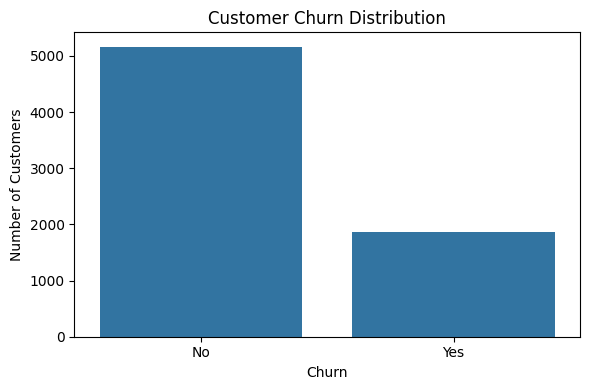

In [12]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("visuals/churn_distribution.png", dpi=150)
plt.show()

### 5.2 Churn by Contract Type

In [13]:
contract_churn = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
contract_churn.round(2)

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.72,11.28
Two year,97.15,2.85


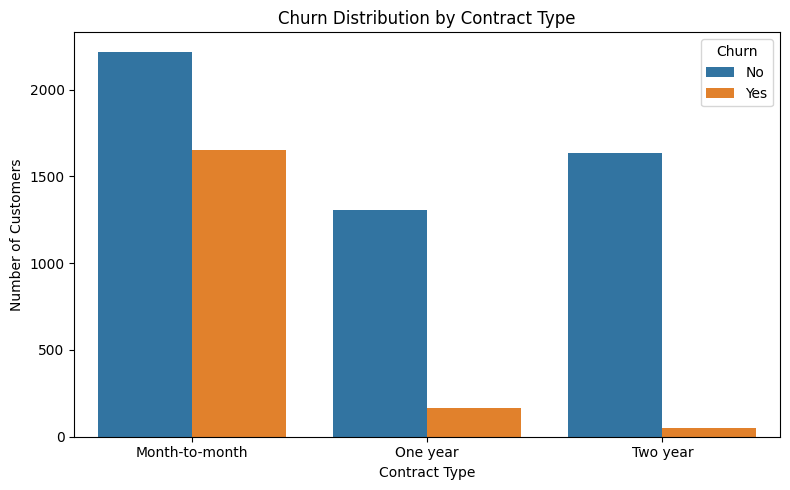

In [14]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn Distribution by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("visuals/contract_churn.png", dpi=150)
plt.show()

### 5.3 Tenure vs Churn

In [15]:
df.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,37.650010,24.076940,1.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


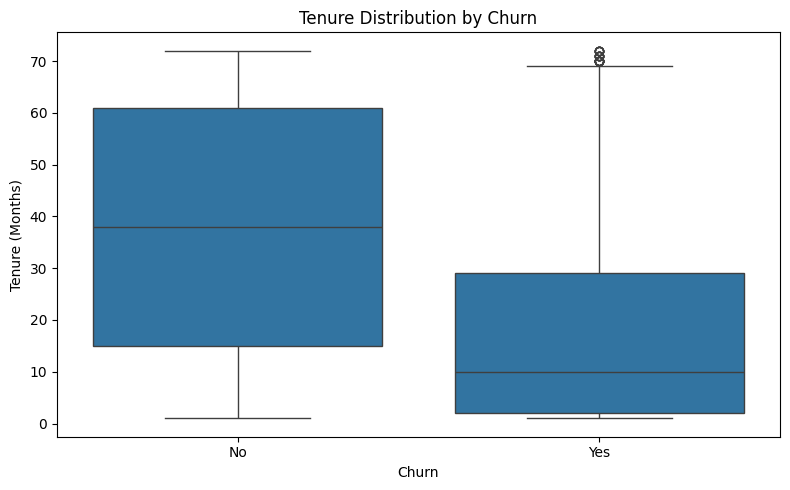

In [16]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Tenure Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.tight_layout()
plt.savefig("visuals/tenure_churn.png", dpi=150)
plt.show()

### 5.4 Monthly Charges vs Churn

In [17]:
df.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,61.307408,31.094557,18.25,25.10,64.45,88.475,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.65,94.200,118.35


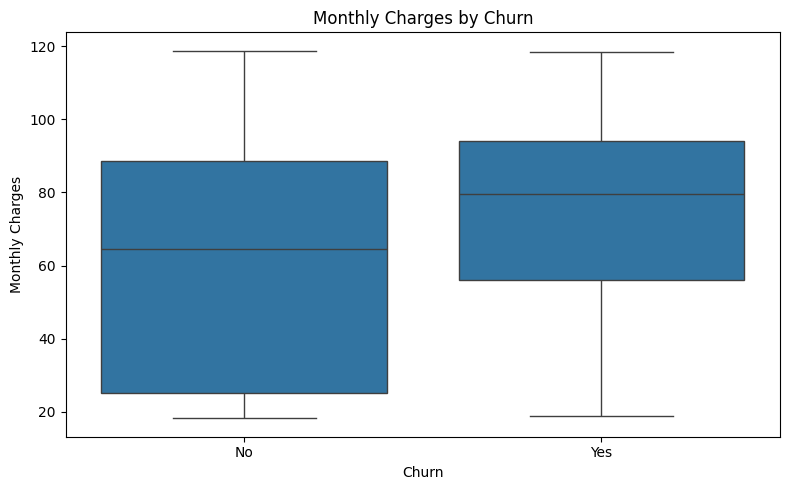

In [18]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.tight_layout()
plt.savefig("visuals/monthlycharges_churn.png", dpi=150)
plt.show()

### 5.5 Churn by Payment Method

In [19]:
payment_churn = pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100
payment_churn.round(2)

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.27,16.73
Credit card (automatic),84.75,15.25
Electronic check,54.71,45.29
Mailed check,80.80,19.20


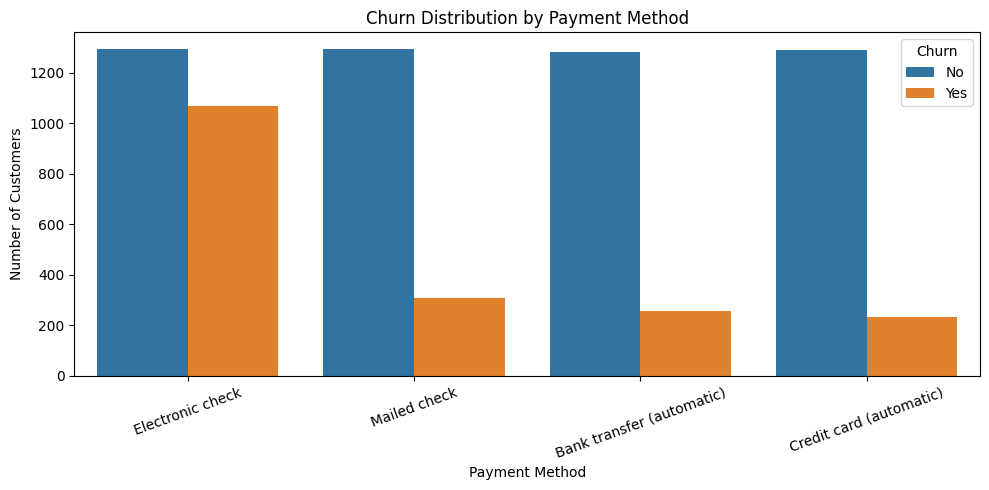

In [20]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="PaymentMethod", hue="Churn")
plt.title("Churn Distribution by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("visuals/payment_churn.png", dpi=150)
plt.show()

### 5.6 Churn by Internet Service

In [21]:
internet_churn = pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100
internet_churn.round(2)

Churn,No,Yes
InternetService,,
DSL,81.00,19.00
Fiber optic,58.11,41.89
No,92.57,7.43


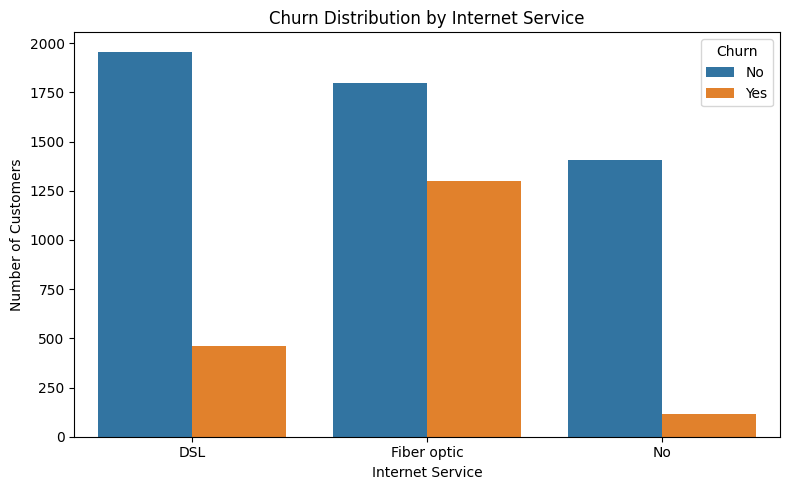

In [22]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="InternetService", hue="Churn")
plt.title("Churn Distribution by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("visuals/internet_churn.png", dpi=150)
plt.show()

### 5.7 Senior Citizen & Gender vs Churn

In [23]:
senior_churn = pd.crosstab(df["SeniorCitizen"], df["Churn"], normalize="index") * 100
senior_churn.round(2)

Churn,No,Yes
SeniorCitizen,,
0,76.35,23.65
1,58.32,41.68


In [24]:
gender_churn = pd.crosstab(df["gender"], df["Churn"], normalize="index") * 100
gender_churn.round(2)

Churn,No,Yes
gender,,
Female,73.04,26.96
Male,73.80,26.20


## 6. Encode Target Variable

In [25]:
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})
df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

## 7. Train-Test Split

In [26]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X shape: (7032, 19)
y shape: (7032,)
X_train: (5625, 19)
X_test : (1407, 19)
y_train: (5625,)
y_test : (1407,)


## 8. Preprocessing Pipeline

In [27]:
numeric_features = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]

categorical_features = [
    "gender", "Partner", "Dependents", "PhoneService", "MultipleLines",
    "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies", "Contract",
    "PaperlessBilling", "PaymentMethod"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
    ]
)

## 9. Model Building

## Why Logistic Regression?

Logistic Regression was chosen as the primary model because it is highly
interpretable — each feature's coefficient directly shows its impact on
churn probability (see Feature Importance section). This is valuable in
a business setting, where stakeholders need to understand *why* a
customer is predicted to churn, not just *that* they will. While more
complex models (Random Forest, XGBoost) could potentially improve raw
accuracy, they trade away this transparency — a key consideration for
customer-retention decisions.

### 9.1 Baseline Logistic Regression

In [28]:
baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

### 9.2 Class-Balanced Logistic Regression

In [29]:
balanced_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

## 10. Cross-Validation Comparison

In [30]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

baseline_cv = cross_validate(
    baseline_model, X_train, y_train, cv=cv,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"]
)

baseline_summary = {
    "Accuracy": baseline_cv["test_accuracy"].mean(),
    "Precision": baseline_cv["test_precision"].mean(),
    "Recall": baseline_cv["test_recall"].mean(),
    "F1": baseline_cv["test_f1"].mean(),
    "ROC-AUC": baseline_cv["test_roc_auc"].mean()
}

baseline_summary

{'Accuracy': np.float64(0.8033777777777777),
 'Precision': np.float64(0.6568231178337799),
 'Recall': np.float64(0.5464882943143812),
 'F1': np.float64(0.5964019339310394),
 'ROC-AUC': np.float64(0.8460801541862706)}

In [31]:
balanced_cv = cross_validate(
    balanced_model, X_train, y_train, cv=cv,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"]
)

balanced_summary = {
    "Accuracy": balanced_cv["test_accuracy"].mean(),
    "Precision": balanced_cv["test_precision"].mean(),
    "Recall": balanced_cv["test_recall"].mean(),
    "F1": balanced_cv["test_f1"].mean(),
    "ROC-AUC": balanced_cv["test_roc_auc"].mean()
}

balanced_summary

{'Accuracy': np.float64(0.7518222222222223),
 'Precision': np.float64(0.5216053819527995),
 'Recall': np.float64(0.8020066889632107),
 'F1': np.float64(0.6320389318307496),
 'ROC-AUC': np.float64(0.8459109056013994)}

In [32]:
model_comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Default Logistic Regression": [
        baseline_summary["Accuracy"], baseline_summary["Precision"],
        baseline_summary["Recall"], baseline_summary["F1"], baseline_summary["ROC-AUC"]
    ],
    "Balanced Logistic Regression": [
        balanced_summary["Accuracy"], balanced_summary["Precision"],
        balanced_summary["Recall"], balanced_summary["F1"], balanced_summary["ROC-AUC"]
    ]
})

model_comparison.round(4)

,Metric,Default Logistic Regression,Balanced Logistic Regression
0,Accuracy,0.8034,0.7518
1,Precision,0.6568,0.5216
2,Recall,0.5465,0.8020
3,F1 Score,0.5964,0.6320
4,ROC-AUC,0.8461,0.8459


## 11. Train Final Model (Balanced Logistic Regression)

In [33]:
balanced_model.fit(X_train, y_train)
print("Balanced Logistic Regression trained successfully!")

Balanced Logistic Regression trained successfully!


## 12. Threshold Tuning

In [34]:
cv_prob = cross_val_predict(
    balanced_model, X_train, y_train, cv=cv, method="predict_proba"
)[:, 1]

In [35]:
threshold_results = []
thresholds = np.arange(0.30, 0.71, 0.05)

for threshold in thresholds:
    y_cv_pred = (cv_prob >= threshold).astype(int)
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_train, y_cv_pred),
        "Recall": recall_score(y_train, y_cv_pred),
        "F1": f1_score(y_train, y_cv_pred)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df.round(3)

,Threshold,Precision,Recall,F1
0,0.30,0.430,0.927,0.588
1,0.35,0.448,0.908,0.600
2,0.40,0.470,0.872,0.611
3,0.45,0.496,0.838,0.623
4,0.50,0.522,0.802,0.632
5,0.55,0.543,0.762,0.634
6,0.60,0.565,0.714,0.631
7,0.65,0.591,0.654,0.621
8,0.70,0.619,0.587,0.603


In [36]:
best_threshold = threshold_df.loc[threshold_df["F1"].idxmax(), "Threshold"]
print("Best Threshold:", best_threshold)

final_threshold = float(best_threshold)

Best Threshold: 0.5499999999999999


## 13. Final Model Training & Test Evaluation

In [37]:
balanced_model.fit(X_train, y_train)

print("Final model trained.")
print("Final threshold:", final_threshold)

Final model trained.
Final threshold: 0.5499999999999999


In [38]:
y_test_prob = balanced_model.predict_proba(X_test)[:, 1]
y_test_final = (y_test_prob >= final_threshold).astype(int)

final_accuracy = accuracy_score(y_test, y_test_final)
final_precision = precision_score(y_test, y_test_final)
final_recall = recall_score(y_test, y_test_final)
final_f1 = f1_score(y_test, y_test_final)
final_roc_auc = roc_auc_score(y_test, y_test_prob)

print("Final Test Results")
print("------------------")
print(f"Accuracy : {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1 Score : {final_f1:.4f}")
print(f"ROC-AUC  : {final_roc_auc:.4f}")

Final Test Results
------------------
Accuracy : 0.7463
Precision: 0.5154
Recall   : 0.7620
F1 Score : 0.6149
ROC-AUC  : 0.8353


In [39]:
print(classification_report(
    y_test, y_test_final, target_names=["No Churn", "Churn"]
))

              precision    recall  f1-score   support

    No Churn       0.90      0.74      0.81      1033
       Churn       0.52      0.76      0.61       374

    accuracy                           0.75      1407
   macro avg       0.71      0.75      0.71      1407
weighted avg       0.79      0.75      0.76      1407



[[765 268]
 [ 89 285]]


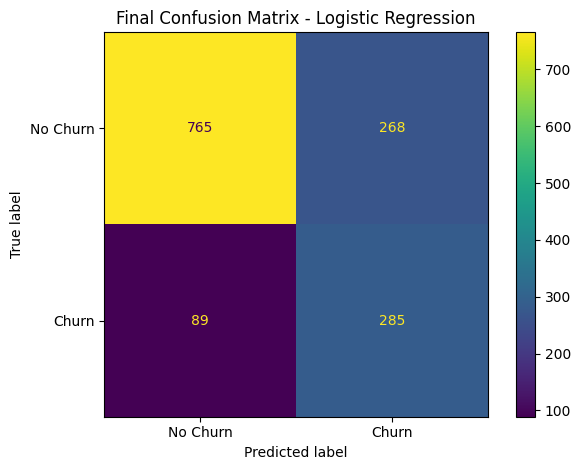

In [40]:
cm = confusion_matrix(y_test, y_test_final)
print(cm)

ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_final, display_labels=["No Churn", "Churn"]
)
plt.title("Final Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.savefig("visuals/confusion_matrix.png", dpi=150)
plt.show()

## 14. Feature Importance

In [41]:
trained_model = balanced_model.named_steps["model"]
feature_names = balanced_model.named_steps["preprocessor"].get_feature_names_out()

coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": trained_model.coef_[0]
})

coefficients = coefficients.sort_values("Coefficient", ascending=False)
coefficients.head(15)

,Feature,Coefficient
10,cat__InternetService_Fiber optic,1.125391
3,num__TotalCharges,0.610057
28,cat__PaymentMethod_Electronic check,0.418495
21,cat__StreamingTV_Yes,0.382479
23,cat__StreamingMovies_Yes,0.367871
9,cat__MultipleLines_Yes,0.335754
26,cat__PaperlessBilling_Yes,0.258044
27,cat__PaymentMethod_Credit card (automatic),0.079969
0,num__SeniorCitizen,0.076025
17,cat__DeviceProtection_Yes,0.069509


In [42]:
top_positive = coefficients.head(10)
top_negative = coefficients.tail(10)

print("Top Positive Features")
print(top_positive)

print("\nTop Negative Features")
print(top_negative)

Top Positive Features
                                       Feature  Coefficient
10            cat__InternetService_Fiber optic     1.125391
3                            num__TotalCharges     0.610057
28         cat__PaymentMethod_Electronic check     0.418495
21                        cat__StreamingTV_Yes     0.382479
23                    cat__StreamingMovies_Yes     0.367871
9                       cat__MultipleLines_Yes     0.335754
26                   cat__PaperlessBilling_Yes     0.258044
27  cat__PaymentMethod_Credit card (automatic)     0.079969
0                           num__SeniorCitizen     0.076025
17                   cat__DeviceProtection_Yes     0.069509

Top Negative Features
                                      Feature  Coefficient
11                    cat__InternetService_No    -0.169810
16  cat__DeviceProtection_No internet service    -0.169810
6                         cat__Dependents_Yes    -0.227448
19                       cat__TechSupport_Yes    -0.309642


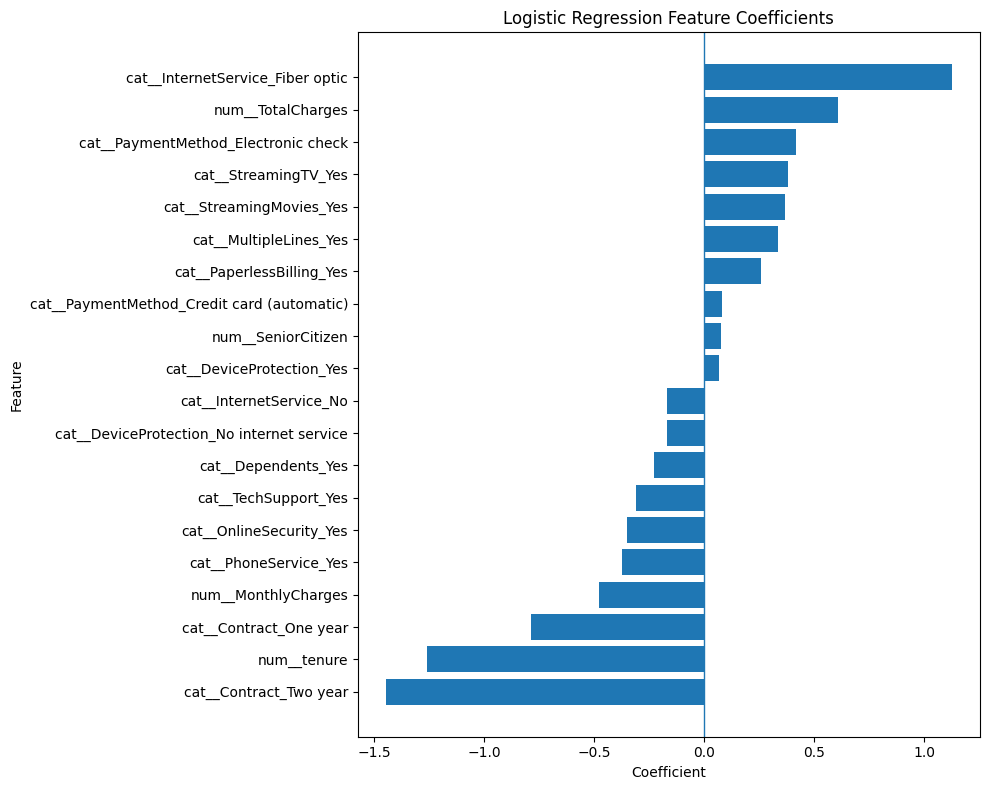

In [43]:
top_features = pd.concat([coefficients.head(10), coefficients.tail(10)]).sort_values("Coefficient")

plt.figure(figsize=(10, 8))
plt.barh(top_features["Feature"], top_features["Coefficient"])
plt.axvline(0, linewidth=1)
plt.title("Logistic Regression Feature Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("visuals/feature_importance.png", dpi=150)
plt.show()

## 15. Reusable Prediction Function

In [44]:
def predict_churn(customer_data, threshold=final_threshold):
    """
    Predict customer churn probability and label.

    Parameters
    ----------
    customer_data : pd.DataFrame
        Customer data with the same feature columns used during training.
    threshold : float
        Probability threshold used to classify churn.

    Returns
    -------
    pd.DataFrame
        Original customer data with Churn_Probability, Churn_Prediction, Churn_Label.
    """
    probabilities = balanced_model.predict_proba(customer_data)[:, 1]
    predictions = (probabilities >= threshold).astype(int)

    result = customer_data.copy()
    result["Churn_Probability"] = probabilities
    result["Churn_Prediction"] = predictions
    result["Churn_Label"] = np.where(predictions == 1, "Yes", "No")

    return result

**Example: predicting on a sample customer**

In [45]:
new_customer = X_test.iloc[[0]].copy()

new_customer["tenure"] = 3
new_customer["Contract"] = "Month-to-month"
new_customer["InternetService"] = "Fiber optic"
new_customer["PaymentMethod"] = "Electronic check"
new_customer["MonthlyCharges"] = 95.0

prediction_result = predict_churn(new_customer)
prediction_result

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn_Probability,Churn_Prediction,Churn_Label
971,Female,0,Yes,Yes,3,Yes,No,Fiber optic,No,Yes,...,Yes,Yes,Month-to-month,Yes,Electronic check,95.0,4542.35,0.928825,1,Yes


## 16. Save Final Model

In [46]:
model_artifact = {
    "model": balanced_model,
    "threshold": final_threshold
}

joblib.dump(model_artifact, "models/customer_churn_logistic_model.pkl")
print("Final model saved successfully!")

Final model saved successfully!


In [47]:
loaded_artifact = joblib.load("models/customer_churn_logistic_model.pkl")
loaded_model = loaded_artifact["model"]
loaded_threshold = loaded_artifact["threshold"]

print("Loaded threshold:", loaded_threshold)

Loaded threshold: 0.5499999999999999
